<a href="https://colab.research.google.com/github/GretelKMendez/Tareas-Mac-IA/blob/main/Copia_de_Credit_card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Para detectar transacciones fraudulentas decidi comparar el modelo de vecinos cercanos y random forest. K-Vecinos cercanos detecta fraudes que "se parecen" físicamente a patrones anteriores. Si un grupo de estafadores usa la misma técnica, KNN los agrupa fácilmente.Random forest en lugar de confiar en una sola "opinión", el modelo entrena muchos árboles independientes y cada uno da su veredicto sobre si una transacción es fraude o no.

Por qué ayuda al fraude: El fraude es un evento muy raro. Un solo árbol puede equivocarse fácilmente (sobreajuste), pero es muy difícil que cientos de árboles se equivoquen al mismo tiempo. Al promediar los votos, el modelo se vuelve extremadamente robusto.

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Carga de datos
df = pd.read_csv('creditcard.csv')

# 1. Limpieza: Eliminamos 'Time' porque es un contador secuencial no predictivo
# Justificación: No aporta información sobre el comportamiento del fraude.
df = df.drop(['Time'], axis=1)

# 2. Escalado: La variable 'Amount' no está en la misma escala que V1-V28
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# 3. Definición de variables
# Usamos V1-V28 y Amount.
X = df.drop('Class', axis=1)
y = df['Class']

# 4. División: Usamos 'stratify' debido al gran desequilibrio (0.17% de fraudes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(df)

               V1         V2        V3        V4        V5        V6  \
0       -1.359807  -0.072781  2.536347  1.378155 -0.338321  0.462388   
1        1.191857   0.266151  0.166480  0.448154  0.060018 -0.082361   
2       -1.358354  -1.340163  1.773209  0.379780 -0.503198  1.800499   
3       -0.966272  -0.185226  1.792993 -0.863291 -0.010309  1.247203   
4       -1.158233   0.877737  1.548718  0.403034 -0.407193  0.095921   
...           ...        ...       ...       ...       ...       ...   
284802 -11.881118  10.071785 -9.834783 -2.066656 -5.364473 -2.606837   
284803  -0.732789  -0.055080  2.035030 -0.738589  0.868229  1.058415   
284804   1.919565  -0.301254 -3.249640 -0.557828  2.630515  3.031260   
284805  -0.240440   0.530483  0.702510  0.689799 -0.377961  0.623708   
284806  -0.533413  -0.189733  0.703337 -0.506271 -0.012546 -0.649617   

              V7        V8        V9       V10  ...       V21       V22  \
0       0.239599  0.098698  0.363787  0.090794  ... -0.01830

In [ ]:
#Vecinos cercanos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, average_precision_score

# Definimos el modelo con 5 vecinos
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predicciones
y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

print("--- Evaluación KNN ---")
print(classification_report(y_test, y_pred_knn))
print(f"AUPRC: {average_precision_score(y_test, y_proba_knn):.4f}")

--- Evaluación KNN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.81      0.85        98

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC: 0.8414


AUPRC: Es el área bajo la curva de Precisión-Recall. En datasets desequilibrados, es mejor que el Accuracy. Un valor cercano a 1 es ideal.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score

# Creamos el modelo
# n_jobs=-1 usa todos los núcleos de tu PC para que sea ultra rápido
rf = RandomForestClassifier(n_estimators=10, class_weight='balanced', n_jobs=-1, random_state=42)

# Entrenamos con el dataset COMPLETO (X_train original)
rf.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("--- Evaluación Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(f"AUPRC: {average_precision_score(y_test, y_proba_rf):.4f}")

--- Evaluación Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUPRC: 0.8376


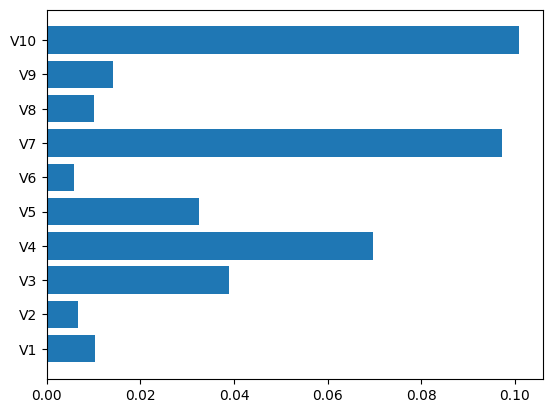

In [ ]:
import matplotlib.pyplot as plt

# Ver qué variables del PCA (V1, V2, etc) son las que más "delatan" al fraude
importances = rf.feature_importances_
plt.barh(X.columns[:10], importances[:10]) # Graficamos las primeras 10
plt.show()